In [123]:
# source: https://youtu.be/fxx_E0ojKrc 

In [124]:
# conda install -c conda-forge statsforecast utilsforecast

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from utilsforecast.plotting import plot_series # type: ignore
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *


## EDA

In [126]:
df = pd.read_csv('dataset/daily_sales_french_bakery.csv', parse_dates=['ds'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 57046 entries, 0 to 57045
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   unique_id   57046 non-null  str           
 1   ds          57046 non-null  datetime64[us]
 2   y           57046 non-null  float64       
 3   unit_price  57046 non-null  float64       
dtypes: datetime64[us](1), float64(2), str(1)
memory usage: 2.4 MB


In [127]:
df.sample(5)

,unique_id,ds,y,unit_price
44372,SACHET VIENNOISERIE,2021-10-21,8.0,4.0
30987,KOUIGN AMANN,2021-09-01,0.0,2.1
4874,BOULE 400G,2022-03-06,20.8,1.6
28784,GD KOUIGN AMANN,2022-01-03,0.0,7.5
16420,DIVERS BOULANGERIE,2021-07-14,4.0,2.0


In [128]:
df['unique_id'].value_counts()

unique_id
BAGUETTE                  637
BANETTE                   637
BANETTINE                 637
BOULE 200G                637
BOULE 400G                637
                         ... 
REDUCTION SUCREES 24        1
SACHET DE VIENNOISERIE      1
TARTELETTE COCKTAIL         1
TROIS CHOCOLAT              1
TULIPE                      1
Name: count, Length: 148, dtype: int64

In [129]:
df = df.groupby('unique_id').filter(lambda x : len(x) >= 28)
df = df.drop('unit_price', axis=1)
df.sample(5)

,unique_id,ds,y
55201,TRIANGLES,2021-11-09,0.0
1479,BAGUETTE GRAINE,2021-08-23,10.4
14054,CROISSANT AMANDES,2022-07-10,6.4
24625,FRAISIER,2021-07-28,0.0
12444,COUPE,2021-08-05,11.7


In [130]:
df['unique_id'].value_counts()

unique_id
BAGUETTE              637
BANETTE               637
BANETTINE             637
BOULE 200G            637
BOULE 400G            637
                     ... 
RELIGIEUSE             71
SABLE F  P             68
DELICETROPICAL         63
VIENNOISE              61
PAIN SUISSE PEPITO     51
Name: count, Length: 121, dtype: int64

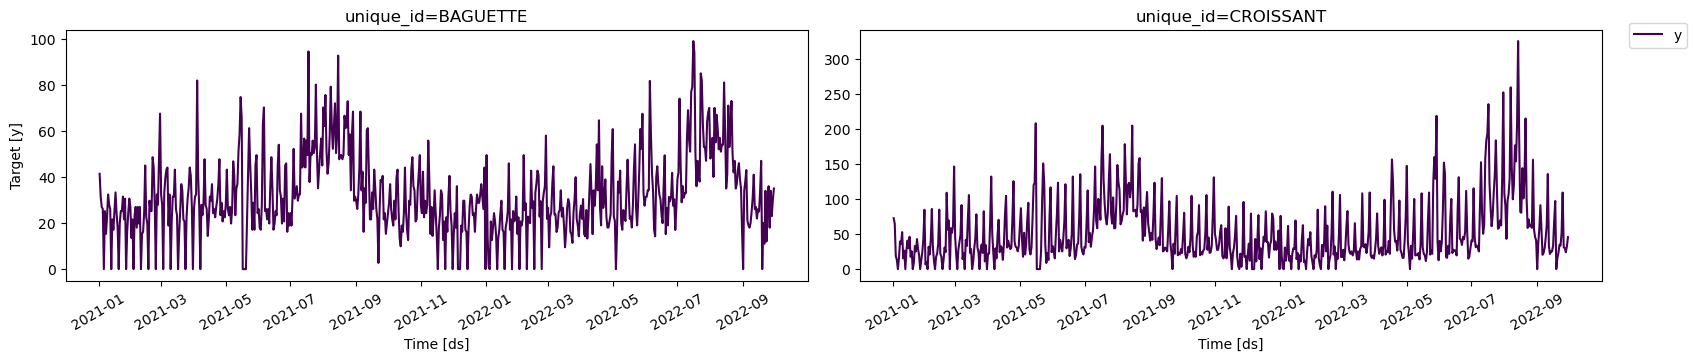

In [131]:
plot_series(df=df, ids=['BAGUETTE', 'CROISSANT'], palette='viridis')

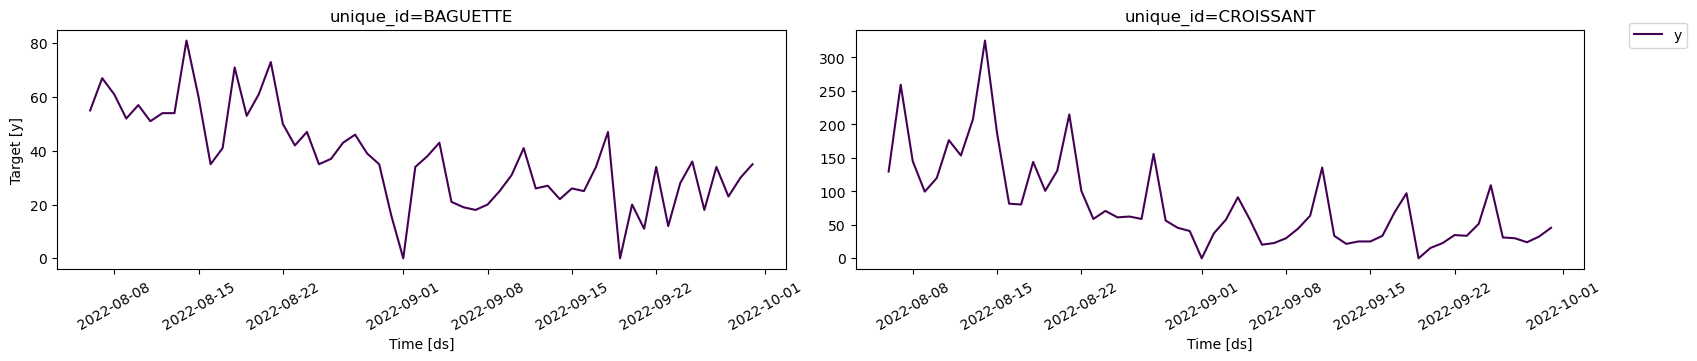

In [132]:

plot_series(df=df, ids=['BAGUETTE', 'CROISSANT'], palette='viridis', max_insample_length=56)

## Baseline Model Training

In [133]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive

In [134]:
horizon = 7
models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=7),
    SeasonalNaive(season_length=7)
]

sf = StatsForecast(models=models, freq='D')
sf.fit(df=df)

preds = sf.predict(h=horizon)

d:\miniconda3\envs\global\Lib\site-packages\statsforecast\core.py:492: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


In [135]:
preds.head(20)

,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
unique_id,,,,,
12 MACARON,2022-09-29,10.0,8.974359,2.857143,0.0
12 MACARON,2022-09-30,10.0,8.974359,2.857143,0.0
12 MACARON,2022-10-01,10.0,8.974359,2.857143,10.0
12 MACARON,2022-10-02,10.0,8.974359,2.857143,0.0
12 MACARON,2022-10-03,10.0,8.974359,2.857143,0.0
12 MACARON,2022-10-04,10.0,8.974359,2.857143,0.0
12 MACARON,2022-10-05,10.0,8.974359,2.857143,10.0
BAGUETTE,2022-10-01,35.0,32.152905,29.142857,28.0
BAGUETTE,2022-10-02,35.0,32.152905,29.142857,36.0


In [136]:
preds = preds.reset_index()
preds

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,2022-09-29,10.000000,8.974359,2.857143,0.000000
1,12 MACARON,2022-09-30,10.000000,8.974359,2.857143,0.000000
2,12 MACARON,2022-10-01,10.000000,8.974359,2.857143,10.000000
3,12 MACARON,2022-10-02,10.000000,8.974359,2.857143,0.000000
4,12 MACARON,2022-10-03,10.000000,8.974359,2.857143,0.000000
...,...,...,...,...,...,...
842,VIK BREAD,2022-10-03,32.400002,14.566091,12.342857,0.000000
843,VIK BREAD,2022-10-04,32.400002,14.566091,12.342857,0.000000
844,VIK BREAD,2022-10-05,32.400002,14.566091,12.342857,0.000000
845,VIK BREAD,2022-10-06,32.400002,14.566091,12.342857,0.000000


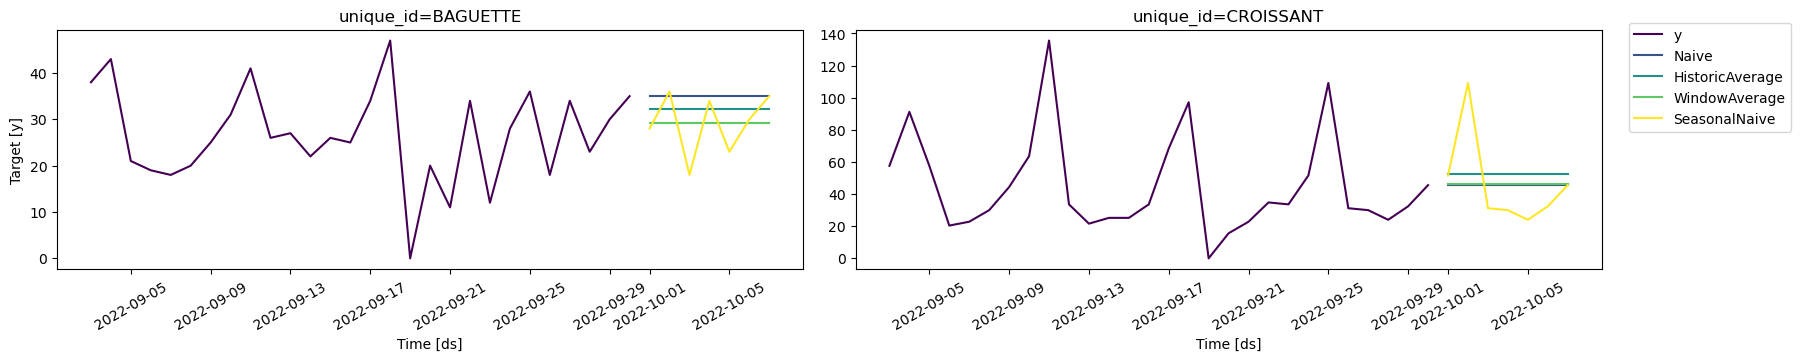

In [137]:
plot_series(df=df, ids=['BAGUETTE', 'CROISSANT'], forecasts_df=preds, max_insample_length=28, palette='viridis')

## Baseline Model Evaluation

In [138]:
test = df.groupby('unique_id').tail(7)
train = df.drop(test.index).reset_index(drop=True)

sf.fit(df=train)
preds = sf.predict(h=horizon)

d:\miniconda3\envs\global\Lib\site-packages\statsforecast\core.py:492: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


In [ ]:

eval_df = pd.merge(test, preds, 'left', ['ds', 'unique_id'])
evaluation = evaluate(df=eval_df, metrics=[mae])
evaluation.head()

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,mae,2.857143,6.961771,3.469388,4.285714
1,BAGUETTE,mae,17.142857,5.455193,7.877551,12.571429
2,BAGUETTE APERO,mae,0.000000,0.537572,0.642857,0.642857
3,BAGUETTE GRAINE,mae,9.800000,4.612271,2.942857,0.200000
4,BANETTE,mae,1.314286,5.421982,6.008163,7.885715


In [149]:
evaluation = evaluation.drop('unique_id', axis=1).groupby('metric').mean().reset_index()
evaluation

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,6.107556,5.228439,5.011663,4.613636


Rectangle(xy=(-0.4, 0), width=0.8, height=6.10756, angle=0)


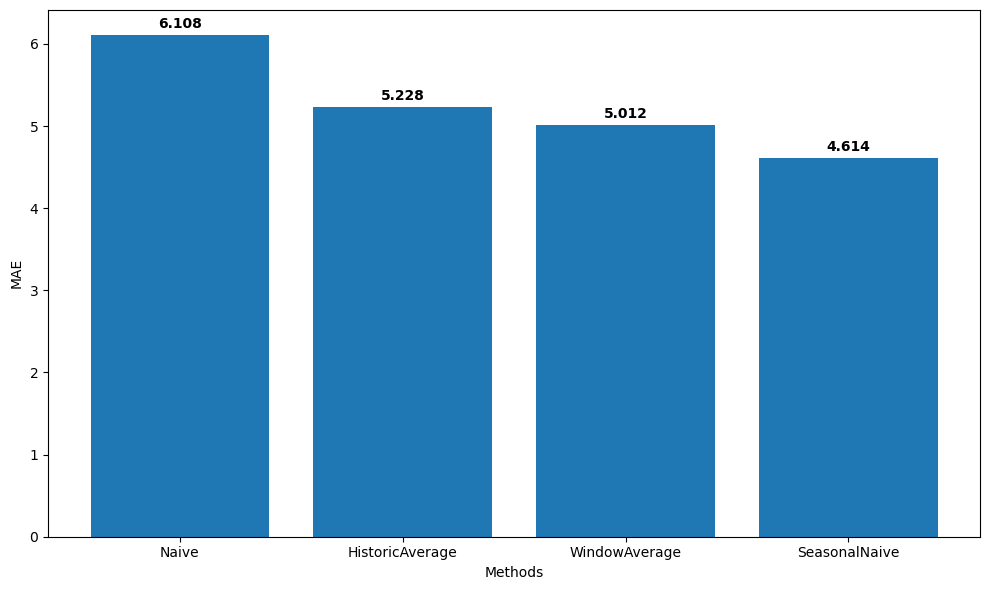

In [193]:
methods = evaluation.columns[1:].tolist()
values = evaluation.iloc[0, 1:].tolist()

plt.figure(figsize=(10,6))
bars = plt.bar(methods, values)
print(bars[0])
for bar, value in zip(bars, values):
    plt.text(
        x=bar.get_x() + bar.get_width()/2, 
        y=bar.get_height() + 0.05,
        s=f'{value:.3f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.xlabel('Methods')
plt.ylabel('MAE')
plt.tight_layout()
# plt.show()